# 多元线性回归-向量化与特征缩放效果对比

这一节使用同一份房价数据，对比两件事的作用：

| 对比项 | 主要影响 |
| --- | --- |
| 不使用向量化 vs 使用向量化 | 代码执行效率 |
| 不做特征缩放 vs 做特征缩放 | 梯度下降收敛速度和稳定性 |

为了让结果可比，四组实验都使用相同的初始参数和相同的迭代次数。

## 1. 读取数据

数据包含 4 个特征：面积、卧室数、楼层、房龄，目标值是房价。

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("data/data_house.csv")

X = data[["x_1(area)", "x_2(bedrooms)", "x_3(floor)", "x_4(age)"]].to_numpy(dtype=float)
y = data["y(price)"].to_numpy(dtype=float)

print(f"样本数量: {X.shape[0]}")
print(f"特征数量: {X.shape[1]}")
data.head()

样本数量: 1000
特征数量: 4


,x_1(area),x_2(bedrooms),x_3(floor),x_4(age),y(price)
0,155.1,3,18,15,354.62
1,172.6,4,6,27,361.22
2,56.9,1,33,1,196.82
3,168.9,4,27,14,414.99
4,90.1,1,11,27,173.83


## 2. 工具函数

这里准备 3 类函数：特征缩放、循环版梯度下降、向量化版梯度下降。两种梯度下降的数学公式相同，差别只在实现方式。

In [2]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma


def compute_cost_loop(X, y, w, b):
    m, n = X.shape
    total_cost = 0.0

    for i in range(m):
        prediction = b
        for j in range(n):
            prediction += w[j] * X[i, j]
        error = prediction - y[i]
        total_cost += error ** 2

    return total_cost / (2 * m)


def compute_gradient_loop(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        prediction = b
        for j in range(n):
            prediction += w[j] * X[i, j]
        error = prediction - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i, j]
        dj_db += error

    return dj_dw / m, dj_db / m


def compute_cost_vectorized(X, y, w, b):
    m = X.shape[0]
    errors = X @ w + b - y
    return np.sum(errors ** 2) / (2 * m)


def compute_gradient_vectorized(X, y, w, b):
    m = X.shape[0]
    errors = X @ w + b - y
    dj_dw = X.T @ errors / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db


def gradient_descent(X, y, alpha, num_iters, vectorized=True):
    w = np.zeros(X.shape[1])
    b = 0.0
    cost_history = []
    cost_fn = compute_cost_vectorized if vectorized else compute_cost_loop
    gradient_fn = compute_gradient_vectorized if vectorized else compute_gradient_loop

    start = time.perf_counter()
    for i in range(num_iters):
        dj_dw, dj_db = gradient_fn(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0 or i == num_iters - 1:
            cost_history.append((i + 1, cost_fn(X, y, w, b)))

    duration = time.perf_counter() - start
    return w, b, np.array(cost_history), duration

## 3. 运行四组实验

原始特征数值范围差异较大，所以使用较小学习率；缩放后特征尺度接近，可以使用更大的学习率。

In [3]:
X_scaled, X_mu, X_sigma = zscore_normalize_features(X)

num_iters = 2000
experiments = [
    {
        "name": "Loop + raw",
        "X": X,
        "alpha": 0.00001,
        "vectorized": False,
        "scaled": False,
    },
    {
        "name": "Vectorized + raw",
        "X": X,
        "alpha": 0.00001,
        "vectorized": True,
        "scaled": False,
    },
    {
        "name": "Loop + scaled",
        "X": X_scaled,
        "alpha": 0.1,
        "vectorized": False,
        "scaled": True,
    },
    {
        "name": "Vectorized + scaled",
        "X": X_scaled,
        "alpha": 0.1,
        "vectorized": True,
        "scaled": True,
    },
]

results = []
histories = {}

for exp in experiments:
    w, b, history, duration = gradient_descent(
        exp["X"],
        y,
        alpha=exp["alpha"],
        num_iters=num_iters,
        vectorized=exp["vectorized"],
    )

    histories[exp["name"]] = history
    results.append(
        {
            "experiment": exp["name"],
            "learning_rate": exp["alpha"],
            "final_cost": history[-1, 1],
            "time_s": duration,
            "time_ms": duration * 1000,
            "scaled": exp["scaled"],
            "w": w,
            "b": b,
        }
    )

summary = pd.DataFrame(results)
summary[["experiment", "learning_rate", "final_cost", "time_s", "time_ms"]]

,experiment,learning_rate,final_cost,time_s,time_ms
0,Loop + raw,0.00001,251.652496,5.453717,5453.7173
1,Vectorized + raw,0.00001,251.652496,0.021256,21.2555
2,Loop + scaled,0.10000,51.815338,6.032455,6032.4550
3,Vectorized + scaled,0.10000,51.815338,0.036461,36.4607


## 4. 耗时对比

循环版和向量化版在同一组输入上计算的是同一个梯度。通常情况下，向量化版会明显更快。

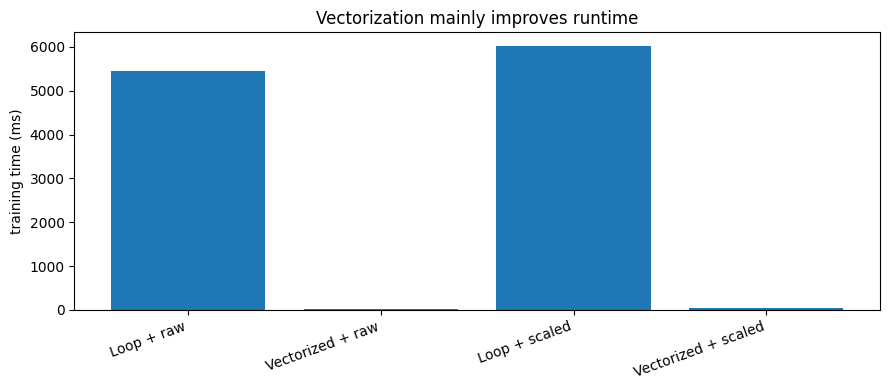

In [4]:
plt.figure(figsize=(9, 4))
plt.bar(summary["experiment"], summary["time_ms"])
plt.ylabel("training time (ms)")
plt.xticks(rotation=20, ha="right")
plt.title("Vectorization mainly improves runtime")
plt.tight_layout()
plt.show()

## 5. 收敛效果对比

特征缩放改变的是输入特征的尺度。缩放后，梯度下降通常能使用更大的学习率，并更快把代价降下来。

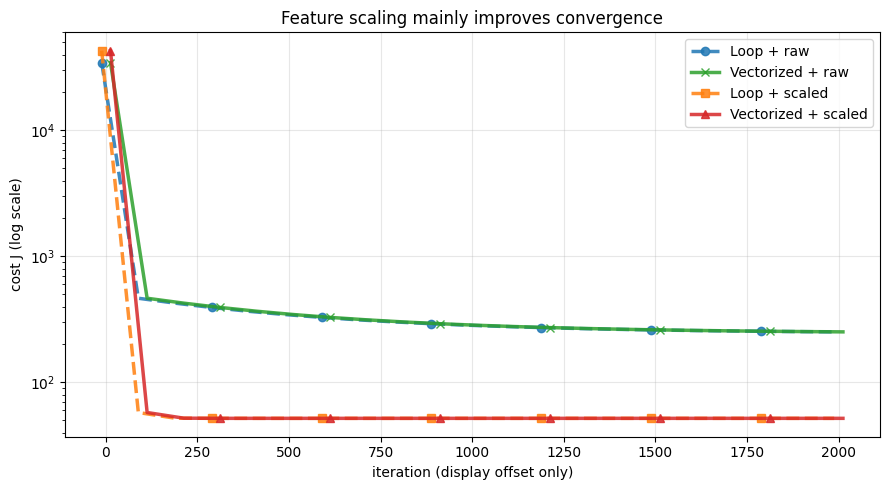

In [5]:
style_config = {
    "Loop + raw": {"color": "tab:blue", "linestyle": "--", "marker": "o", "offset": -12},
    "Vectorized + raw": {"color": "tab:green", "linestyle": "-", "marker": "x", "offset": 12},
    "Loop + scaled": {"color": "tab:orange", "linestyle": "--", "marker": "s", "offset": -12},
    "Vectorized + scaled": {"color": "tab:red", "linestyle": "-", "marker": "^", "offset": 12},
}

plt.figure(figsize=(9, 5))

for name, history in histories.items():
    style = style_config[name]
    display_iterations = history[:, 0] + style["offset"]
    plt.plot(
        display_iterations,
        history[:, 1],
        label=name,
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markevery=3,
        linewidth=2.5,
        alpha=0.85,
    )

plt.yscale("log")
plt.xlabel("iteration (display offset only)")
plt.ylabel("cost J (log scale)")
plt.title("Feature scaling mainly improves convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 预测结果检查

下面用同一套样本检查最终模型的预测误差。注意：缩放后的模型在预测时也必须先用训练集的均值和标准差处理输入特征。

In [6]:
sample_index = 0
sample_raw = X[sample_index]
sample_scaled = (sample_raw - X_mu) / X_sigma
actual_price = y[sample_index]

for item in results:
    uses_scaled_features = item["scaled"]
    sample = sample_scaled if uses_scaled_features else sample_raw
    prediction = sample @ item["w"] + item["b"]
    print(f"{item['experiment']}: predicted {prediction:.2f}, actual {actual_price:.2f}, error {prediction - actual_price:.2f}")

Loop + raw: predicted 367.01, actual 354.62, error 12.39
Vectorized + raw: predicted 367.01, actual 354.62, error 12.39
Loop + scaled: predicted 364.59, actual 354.62, error 9.97
Vectorized + scaled: predicted 364.59, actual 354.62, error 9.97


## 7. 小结

| 组合 | 观察重点 |
| --- | --- |
| 循环版 + 未缩放 | 代码慢，且只能使用较小学习率 |
| 向量化 + 未缩放 | 代码更快，但收敛问题仍然存在 |
| 循环版 + 已缩放 | 收敛更好，但 Python 循环仍然慢 |
| 向量化 + 已缩放 | 既利用 NumPy 提升计算效率，又通过缩放改善梯度下降 |

向量化主要解决计算效率问题；特征缩放主要解决训练收敛问题。两者关注点不同，但可以同时使用。